# Experiment - Does the JFDS Equation Actually Matter?
### Adaptive-λ JScore vs. Plain Relevance-Only Top-K, on MovieLens 1M

**What this notebook tests**

The original implementation (`jfds_implementation.ipynb`) swept λ_f and λ_d as
**fixed constants per run** to find a single best static configuration.

This notebook tests a different question: *what if λ_f and λ_d are not fixed
at all, but change as the list is built?* Specifically, we make them an
**iterative variable tied to list position k**:

- Early in the list (k small) → stay **utility-heavy** (trust relevance).
- Later in the list (k large) → shift weight **toward fairness and diversity**
  (the list already has its "obvious" picks, so spend the remaining slots
  correcting for popularity bias and redundancy).

We then compare this **adaptive-λ JScore** against a **plain Top-K by
relevance only** (i.e. `λ_f = λ_d = 0` for every slot — the equation switched
off entirely) to see what difference the JFDS machinery actually makes:

1. Are the recommended lists themselves different (item overlap)?
2. Do the fairness / diversity / JFDS metrics actually move?
3. What's given up on relevance/utility to get there?

> **No results are computed or interpreted here.** All cells are ready to
> run — you execute and analyse.


---
## Part 0 — Recap: The JFDS Equation

$$\text{JScore}(i,\,S) = \underbrace{(1-\lambda_f-\lambda_d)}_{\lambda_u}\cdot\text{rel}(i) \;+\; \lambda_f\cdot\text{fair\_boost}(i) \;+\; \lambda_d\cdot\text{div}(i,\,S)$$

$$\text{JFDS} = \text{ItemFairness} \times \text{AggregateDiversity}$$

In the original notebook, λ_f and λ_d were **constants for an entire run**
(swept across a grid, e.g. λ_f=0.2, λ_d=0.1 for the whole top-10 list).

### The adaptive-λ schedule used in this experiment

For a list of length $K$, at greedy step $k$ (0-indexed, $k = 0, \dots, K-1$),
define a progress fraction:

$$t_k = \frac{k}{K-1} \qquad (t_0 = 0 \text{ at the first slot}, \; t_{K-1} = 1 \text{ at the last slot})$$

and let λ_f, λ_d **grow with $t_k$** from a low starting weight to a high
ending weight:

$$\lambda_f(k) = \lambda_f^{start} + \big(\lambda_f^{end} - \lambda_f^{start}\big)\cdot t_k^{\,p}$$

$$\lambda_d(k) = \lambda_d^{start} + \big(\lambda_d^{end} - \lambda_d^{start}\big)\cdot t_k^{\,p}$$

with $\lambda_u(k) = 1 - \lambda_f(k) - \lambda_d(k)$ recomputed every step
(simplex constraint still holds at every k). The exponent $p$ controls the
shape of the ramp ($p=1$ linear, $p>1$ back-loaded, $p<1$ front-loaded).

This is exactly what's meant by "λ as an iterative variable that changes
with the configuration of f and d as the list is built" — at every greedy
step the weights are recomputed before scoring candidates.


---
## Part 1 — Setup & Data Loading

Same loading logic as the original implementation notebook, pointed at the
uploaded `.dat` files.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
np.random.seed(42)

print('Libraries loaded ✓')


Libraries loaded ✓


In [3]:
DATA_DIR = '../dataset/movie_lens'

ratings = pd.read_csv(
    f'{DATA_DIR}/ratings.dat', sep='::', engine='python', header=None,
    names=['UserID', 'MovieID', 'Rating', 'Timestamp']
)
movies = pd.read_csv(
    f'{DATA_DIR}/movies.dat', sep='::', engine='python', header=None,
    names=['MovieID', 'Title', 'Genres'], encoding='latin-1'
)
users = pd.read_csv(
    f'{DATA_DIR}/users.dat', sep='::', engine='python', header=None,
    names=['UserID', 'Gender', 'Age', 'Occupation', 'Zip']
)

print(f'Ratings : {len(ratings):,}')
print(f'Movies  : {len(movies):,}')
print(f'Users   : {ratings["UserID"].nunique():,}')
print(f'Matrix density: {len(ratings) / (ratings["UserID"].nunique() * movies["MovieID"].nunique()) * 100:.4f}%')

print('\n--- Ratings sample ---')
print(ratings.head(3).to_string(index=False))
print('\n--- Movies sample ---')
print(movies.head(3).to_string(index=False))


Ratings : 1,000,209
Movies  : 3,883
Users   : 6,040
Matrix density: 4.2647%

--- Ratings sample ---
 UserID  MovieID  Rating  Timestamp
      1     1193       5  978300760
      1      661       3  978302109
      1      914       3  978301968

--- Movies sample ---
 MovieID                   Title                       Genres
       1        Toy Story (1995)  Animation|Children's|Comedy
       2          Jumanji (1995) Adventure|Children's|Fantasy
       3 Grumpier Old Men (1995)               Comedy|Romance


In [4]:
# ── Item-level exposure, popularity, genre encoding, relevance ─────────────
item_stats = (
    ratings.groupby('MovieID')
    .agg(n_ratings=('Rating','count'), mean_rating=('Rating','mean'), n_users=('UserID','nunique'))
    .reset_index()
)

pop_threshold = item_stats['n_ratings'].quantile(0.80)
item_stats['is_popular'] = (item_stats['n_ratings'] >= pop_threshold).astype(int)

total_ratings = item_stats['n_ratings'].sum()
popular_share = item_stats.loc[item_stats['is_popular']==1,'n_ratings'].sum() / total_ratings * 100

print(f'Popularity threshold (80th pct) : {pop_threshold:.0f} ratings')
print(f'Popular items  : {item_stats["is_popular"].sum():,}  ({item_stats["is_popular"].mean()*100:.1f}% of catalogue)')
print(f'Niche items    : {(item_stats["is_popular"]==0).sum():,}')
print(f'Popular items receive {popular_share:.1f}% of all ratings (80/20 rule)')

# Genre one-hot (for cosine diversity)
movies_exp = movies.copy()
movies_exp['Genre'] = movies_exp['Genres'].str.split('|')
movies_exp = movies_exp.explode('Genre')
genre_dummies = (
    pd.get_dummies(movies_exp[['MovieID','Genre']], columns=['Genre'])
    .groupby('MovieID').max()
)
genre_dummies.columns = [c.replace('Genre_','') for c in genre_dummies.columns]
genre_cols = genre_dummies.columns.tolist()
item_stats = item_stats.merge(genre_dummies, on='MovieID', how='left')

# Bayesian-smoothed relevance → [0,1]
global_mean = ratings['Rating'].mean()
m = 10
item_stats['rel'] = (
    (item_stats['n_ratings'] * item_stats['mean_rating'] + m * global_mean)
    / (item_stats['n_ratings'] + m)
)
item_stats['rel'] = (
    (item_stats['rel'] - item_stats['rel'].min())
    / (item_stats['rel'].max() - item_stats['rel'].min())
)

print(f'\nGenre dimensions : {len(genre_cols)}')
print(f'Relevance range  : [{item_stats["rel"].min():.4f}, {item_stats["rel"].max():.4f}]')
print('Data preparation complete ✓')

# Pre-compute L2-normalised genre matrix
item_stats_idx = item_stats.reset_index(drop=True)
genre_mat      = item_stats_idx[genre_cols].fillna(0).values.astype(float)
norms          = np.linalg.norm(genre_mat, axis=1, keepdims=True)
norms[norms==0] = 1
genre_mat_norm = genre_mat / norms
mid_to_idx     = {mid:idx for idx,mid in enumerate(item_stats_idx['MovieID'])}

print(f'Genre matrix shape : {genre_mat_norm.shape}')


Popularity threshold (80th pct) : 429 ratings
Popular items  : 743  (20.0% of catalogue)
Niche items    : 2,963
Popular items receive 65.2% of all ratings (80/20 rule)

Genre dimensions : 18
Relevance range  : [0.0000, 1.0000]
Data preparation complete ✓
Genre matrix shape : (3706, 18)


---
## Part 2 — Two Selection Strategies

### Strategy A — Plain Top-K (relevance only, equation switched OFF)

This is the "not using it" baseline: simple ranking by `rel(i)` alone. No
fairness boost, no diversity term, no λ at all. Equivalent to setting
λ_f = λ_d = 0 for every slot.

### Strategy B — Adaptive-λ JScore (equation switched ON, iterative λ)

The greedy MMR-style selection from the implementation notebook, but instead
of passing in fixed `lf`/`ld`, the weights are recomputed at every step `k`
from the position-based schedule defined in Part 0.


In [5]:
# ── Strategy A: Plain Top-K by relevance only ──────────────────────────────
def build_topk_plain(cand_df, K=10):
    """
    Baseline: rank candidates by rel(i) only, no fairness/diversity term.
    Equivalent to JScore with lambda_f = lambda_d = 0 at every step.
    """
    ranked = cand_df.sort_values('rel', ascending=False)
    return ranked.index[:K].tolist()


print('Strategy A (plain Top-K by relevance) defined ✓')


Strategy A (plain Top-K by relevance) defined ✓


In [6]:
# ── Adaptive λ schedule ─────────────────────────────────────────────────────
def lambda_schedule(k, K, lf_start, lf_end, ld_start, ld_end, p=1.0):
    """
    Position-dependent lambda_f, lambda_d for greedy step k (0-indexed) out of K.

    t_k = k / (K-1) in [0, 1]   (0 at first slot, 1 at last slot)
    lambda_f(k) = lf_start + (lf_end - lf_start) * t_k**p
    lambda_d(k) = ld_start + (ld_end - ld_start) * t_k**p

    p = 1   -> linear ramp
    p > 1   -> back-loaded (stays utility-heavy longer, then ramps fast near the end)
    p < 1   -> front-loaded (ramps fast early, then levels off)
    """
    t_k = 0.0 if K <= 1 else k / (K - 1)
    lf_k = lf_start + (lf_end - lf_start) * (t_k ** p)
    ld_k = ld_start + (ld_end - ld_start) * (t_k ** p)
    # Safety clip to keep the simplex constraint valid (lf + ld <= 1, both >= 0)
    lf_k = max(0.0, lf_k)
    ld_k = max(0.0, ld_k)
    if lf_k + ld_k > 1.0:
        scale = 1.0 / (lf_k + ld_k)
        lf_k *= scale
        ld_k *= scale
    return lf_k, ld_k


# Quick sanity preview of the schedule for a K=10 list
SCHEDULE_PARAMS = dict(lf_start=0.05, lf_end=0.45, ld_start=0.05, ld_end=0.35, p=1.0)

preview = pd.DataFrame([
    {'k': k, 'lf(k)': lambda_schedule(k, 10, **SCHEDULE_PARAMS)[0],
             'ld(k)': lambda_schedule(k, 10, **SCHEDULE_PARAMS)[1]}
    for k in range(10)
])
preview['lu(k)'] = 1 - preview['lf(k)'] - preview['ld(k)']
print('Lambda schedule preview (K=10 slots):')
print(preview.to_string(index=False))


Lambda schedule preview (K=10 slots):
 k    lf(k)    ld(k)    lu(k)
 0 0.050000 0.050000 0.900000
 1 0.094444 0.083333 0.822222
 2 0.138889 0.116667 0.744444
 3 0.183333 0.150000 0.666667
 4 0.227778 0.183333 0.588889
 5 0.272222 0.216667 0.511111
 6 0.316667 0.250000 0.433333
 7 0.361111 0.283333 0.355556
 8 0.405556 0.316667 0.277778
 9 0.450000 0.350000 0.200000


In [7]:
# ── Strategy B: Adaptive-λ JScore (greedy, position-dependent weights) ─────
def cosine_div(i_idx, selected_idxs):
    """Mean cosine distance between item i and the selected set (genre space)."""
    if len(selected_idxs) == 0:
        return 0.5  # neutral prior for empty list
    sims = genre_mat_norm[i_idx] @ genre_mat_norm[selected_idxs].T
    return float(1.0 - sims.mean())


def build_topk_adaptive(cand_df, cand_idxs, K=10, schedule_params=None):
    """
    Greedy MMR-style selection using JScore, but lambda_f / lambda_d are
    recomputed at every step k from lambda_schedule() instead of being fixed
    for the whole list.

    JScore(i, S; k) = (1 - lf(k) - ld(k)) * rel(i) + lf(k) * fair_boost(i) + ld(k) * div(i, S)
    """
    if schedule_params is None:
        schedule_params = SCHEDULE_PARAMS

    rel        = cand_df['rel'].values
    fair_boost = (1 - cand_df['is_popular'].values).astype(float)
    mat_idxs   = np.array(cand_idxs)

    selected_pos   = []
    selected_midx  = []
    lambda_trace   = []  # record (k, lf_k, ld_k, lu_k) actually used at each step
    remaining      = list(range(len(cand_df)))
    n_steps        = min(K, len(remaining))

    for k in range(n_steps):
        lf_k, ld_k = lambda_schedule(k, n_steps, **schedule_params)
        lu_k = 1.0 - lf_k - ld_k
        lambda_trace.append({'k': k, 'lf_k': lf_k, 'ld_k': ld_k, 'lu_k': lu_k})

        rem = np.array(remaining)
        base_scores = lu_k * rel[rem] + lf_k * fair_boost[rem]

        best_score, best_pos = -np.inf, None
        for j, pos in enumerate(remaining):
            div   = cosine_div(mat_idxs[pos], selected_midx)
            score = base_scores[j] + ld_k * div
            if score > best_score:
                best_score, best_pos = score, pos

        selected_pos.append(best_pos)
        selected_midx.append(mat_idxs[best_pos])
        remaining.remove(best_pos)

    return selected_pos, lambda_trace


print('Strategy B (adaptive-λ JScore) defined ✓')
print()
print('JScore(i, S; k) = (1 - λ_f(k) - λ_d(k))·rel(i) + λ_f(k)·fair_boost(i) + λ_d(k)·div(i,S)')
print('λ_f(k), λ_d(k) recomputed every greedy step from the position schedule (Part 0)')


Strategy B (adaptive-λ JScore) defined ✓

JScore(i, S; k) = (1 - λ_f(k) - λ_d(k))·rel(i) + λ_f(k)·fair_boost(i) + λ_d(k)·div(i,S)
λ_f(k), λ_d(k) recomputed every greedy step from the position schedule (Part 0)


---
## Part 3 — Sanity Check: One User, Side by Side

Before running the full comparison across many users, sanity-check the two
strategies on a single user: print both Top-10 lists, their λ-trace
(Strategy B only), and the genre composition of each list.


In [8]:
# ── Single-user sanity check ────────────────────────────────────────────────
SAMPLE_USER_ID   = ratings['UserID'].drop_duplicates().sample(1, random_state=7).iloc[0]
N_CANDIDATES_DEMO = 150
K_DEMO            = 10

user_rated_demo = ratings.groupby('UserID')['MovieID'].apply(set).to_dict()
rated_ids_demo  = user_rated_demo.get(SAMPLE_USER_ID, set())

mask_demo    = ~item_stats_idx['MovieID'].isin(rated_ids_demo)
cand_pool_demo = item_stats_idx[mask_demo]
cand_df_demo   = cand_pool_demo.sample(min(N_CANDIDATES_DEMO, len(cand_pool_demo)), random_state=int(SAMPLE_USER_ID))
cand_idxs_demo = [mid_to_idx[mid] for mid in cand_df_demo['MovieID']]
cand_df_demo_r = cand_df_demo.reset_index(drop=True)

# Strategy A
pos_a_demo = build_topk_plain(cand_df_demo_r, K=K_DEMO)
list_a_demo = cand_df_demo_r.loc[pos_a_demo].merge(movies[['MovieID','Title','Genres']], on='MovieID')

# Strategy B
pos_b_demo, trace_b_demo = build_topk_adaptive(cand_df_demo_r, cand_idxs_demo, K=K_DEMO)
list_b_demo = cand_df_demo_r.iloc[pos_b_demo].merge(movies[['MovieID','Title','Genres']], on='MovieID')

print(f'Sample user: {SAMPLE_USER_ID}  (already rated {len(rated_ids_demo)} movies)')
print()
print('=== Strategy A — Plain Top-K (relevance only) ===')
print(list_a_demo[['MovieID','Title','Genres','rel','is_popular']].to_string(index=False))
print()
print('=== Strategy B — Adaptive-λ JScore ===')
print(list_b_demo[['MovieID','Title','Genres','rel','is_popular']].to_string(index=False))
print()
print('=== λ trace used by Strategy B for this list ===')
print(pd.DataFrame(trace_b_demo).to_string(index=False))


Sample user: 1902  (already rated 258 movies)

=== Strategy A — Plain Top-K (relevance only) ===
 MovieID                                                                           Title                     Genres      rel  is_popular
     527                                                         Schindler's List (1993)                  Drama|War 0.985003           1
     908                                                       North by Northwest (1959)             Drama|Thriller 0.941033           1
    1252                                                                Chinatown (1974) Film-Noir|Mystery|Thriller 0.925601           1
    3429                                                        Creature Comforts (1990)           Animation|Comedy 0.917491           0
    1260                                                                        M (1931)   Crime|Film-Noir|Thriller 0.907249           0
    1217                                                                      Ran

In [9]:
# ── Overlap between the two lists for this single user ─────────────────────
ids_a_demo = set(list_a_demo['MovieID'])
ids_b_demo = set(list_b_demo['MovieID'])
overlap_demo = ids_a_demo & ids_b_demo

print(f'Strategy A list  : {sorted(ids_a_demo)}')
print(f'Strategy B list  : {sorted(ids_b_demo)}')
print(f'Overlap (same items in both lists) : {len(overlap_demo)} / {K_DEMO}')
print(f'Items in A only  : {sorted(ids_a_demo - ids_b_demo)}')
print(f'Items in B only  : {sorted(ids_b_demo - ids_a_demo)}')


Strategy A list  : [363, 527, 908, 1217, 1252, 1260, 2203, 2936, 3095, 3429]
Strategy B list  : [363, 527, 1217, 1260, 1484, 2203, 2921, 2936, 3153, 3429]
Overlap (same items in both lists) : 7 / 10
Items in A only  : [908, 1252, 3095]
Items in B only  : [1484, 2921, 3153]


---
## Part 4 — Full Comparison Across Many Users

Run both strategies for a sample of users and collect, per user:

- the Top-K list itself (for overlap analysis),
- niche fraction (item fairness contribution),
- intra-list diversity (ILD),

then aggregate into:

- **Item Fairness** (mean niche fraction across users)
- **Aggregate Diversity** (unique catalogue coverage across all users' lists)
- **ILD** (mean intra-list genre diversity)
- **JFDS** = Fairness × AggDiv
- **Mean relevance@K** (utility/accuracy proxy — what's traded away)
- **List overlap@K** (Jaccard / count overlap between A and B per user)


In [10]:
# ── Full comparison setup ───────────────────────────────────────────────────
N_USERS      = 300
K_RECS       = 10
N_CANDIDATES = 150

sampled_users = (
    ratings['UserID'].drop_duplicates()
    .sample(N_USERS, random_state=42)
    .values
)
user_rated = ratings.groupby('UserID')['MovieID'].apply(set).to_dict()

print(f'Users sampled     : {N_USERS}')
print(f'Candidates / user : {N_CANDIDATES}')
print(f'List length K     : {K_RECS}')
print(f'Lambda schedule   : {SCHEDULE_PARAMS}')
print('Running comparison...\n')

def ild_for_list(sel_gidxs):
    if len(sel_gidxs) <= 1:
        return None
    vecs    = genre_mat_norm[sel_gidxs]
    sim_mat = vecs @ vecs.T
    np.fill_diagonal(sim_mat, 1.0)
    mask_ut = np.triu(np.ones_like(sim_mat, dtype=bool), k=1)
    return float(1 - sim_mat[mask_ut].mean())


results_a = {'all_selected_ids': set(), 'niche_frac': [], 'ild': [], 'mean_rel': [], 'lists': {}}
results_b = {'all_selected_ids': set(), 'niche_frac': [], 'ild': [], 'mean_rel': [], 'lists': {}}
overlap_counts = []

for uid in sampled_users:
    rated_ids = user_rated.get(uid, set())
    mask      = ~item_stats_idx['MovieID'].isin(rated_ids)
    cand_pool = item_stats_idx[mask]
    n_cand    = min(N_CANDIDATES, len(cand_pool))
    cand_df   = cand_pool.sample(n_cand, random_state=int(uid)).reset_index(drop=True)
    cand_idxs = [mid_to_idx[mid] for mid in cand_df['MovieID']]

    # --- Strategy A: plain Top-K ---
    pos_a   = build_topk_plain(cand_df, K=K_RECS)
    sel_a   = cand_df.iloc[pos_a]
    sel_a_mids  = sel_a['MovieID'].tolist()
    sel_a_gidxs = [mid_to_idx[m] for m in sel_a_mids]

    results_a['all_selected_ids'].update(sel_a_mids)
    results_a['niche_frac'].append(1.0 - sel_a['is_popular'].mean())
    results_a['mean_rel'].append(sel_a['rel'].mean())
    ild_a = ild_for_list(sel_a_gidxs)
    if ild_a is not None:
        results_a['ild'].append(ild_a)
    results_a['lists'][uid] = set(sel_a_mids)

    # --- Strategy B: adaptive-λ JScore ---
    pos_b, _ = build_topk_adaptive(cand_df, cand_idxs, K=K_RECS)
    sel_b    = cand_df.iloc[pos_b]
    sel_b_mids  = sel_b['MovieID'].tolist()
    sel_b_gidxs = [mid_to_idx[m] for m in sel_b_mids]

    results_b['all_selected_ids'].update(sel_b_mids)
    results_b['niche_frac'].append(1.0 - sel_b['is_popular'].mean())
    results_b['mean_rel'].append(sel_b['rel'].mean())
    ild_b = ild_for_list(sel_b_gidxs)
    if ild_b is not None:
        results_b['ild'].append(ild_b)
    results_b['lists'][uid] = set(sel_b_mids)

    # --- per-user overlap between A and B ---
    overlap_counts.append(len(set(sel_a_mids) & set(sel_b_mids)))

print('Per-user loop complete ✓')


Users sampled     : 300
Candidates / user : 150
List length K     : 10
Lambda schedule   : {'lf_start': 0.05, 'lf_end': 0.45, 'ld_start': 0.05, 'ld_end': 0.35, 'p': 1.0}
Running comparison...

Per-user loop complete ✓


In [11]:
# ── Aggregate metrics: Strategy A vs Strategy B ────────────────────────────
def summarize(results, label, n_items_catalogue):
    fairness = float(np.mean(results['niche_frac']))
    agg_div  = len(results['all_selected_ids']) / n_items_catalogue
    ild      = float(np.mean(results['ild'])) if results['ild'] else 0.0
    mean_rel = float(np.mean(results['mean_rel']))
    jfds     = fairness * agg_div
    return {
        'Strategy': label,
        'Fairness (niche frac)': fairness,
        'AggDiv (catalogue coverage)': agg_div,
        'ILD': ild,
        'JFDS': jfds,
        'Mean rel@K (utility)': mean_rel,
    }

n_items_catalogue = len(item_stats_idx)

summary_a = summarize(results_a, 'A — Plain Top-K (relevance only)', n_items_catalogue)
summary_b = summarize(results_b, 'B — Adaptive-λ JScore', n_items_catalogue)

summary_df = pd.DataFrame([summary_a, summary_b]).set_index('Strategy')
print('=== Strategy comparison: aggregate metrics ===')
print(summary_df.to_string())

print()
print('=== Per-user list overlap (Strategy A vs Strategy B) ===')
overlap_arr = np.array(overlap_counts)
print(f'Mean overlap@{K_RECS}     : {overlap_arr.mean():.2f} items  ({overlap_arr.mean()/K_RECS*100:.1f}% of the list)')
print(f'Median overlap@{K_RECS}   : {np.median(overlap_arr):.1f} items')
print(f'Min / Max overlap   : {overlap_arr.min()} / {overlap_arr.max()} items')
print(f'Users with 0 overlap (fully different lists) : {(overlap_arr==0).sum()} / {len(overlap_arr)}')


=== Strategy comparison: aggregate metrics ===
                                  Fairness (niche frac)  AggDiv (catalogue coverage)       ILD      JFDS  Mean rel@K (utility)
Strategy                                                                                                                      
A — Plain Top-K (relevance only)               0.490333                     0.116298  0.740593  0.057025              0.871677
B — Adaptive-λ JScore                          0.958000                     0.153265  0.953105  0.146828              0.796009

=== Per-user list overlap (Strategy A vs Strategy B) ===
Mean overlap@10     : 4.29 items  (42.9% of the list)
Median overlap@10   : 4.0 items
Min / Max overlap   : 2 / 8 items
Users with 0 overlap (fully different lists) : 0 / 300


---
## Part 5 — Visual Comparison

Side-by-side bar charts for the four headline metrics, plus a histogram of
per-user list overlap, plus a delta table.


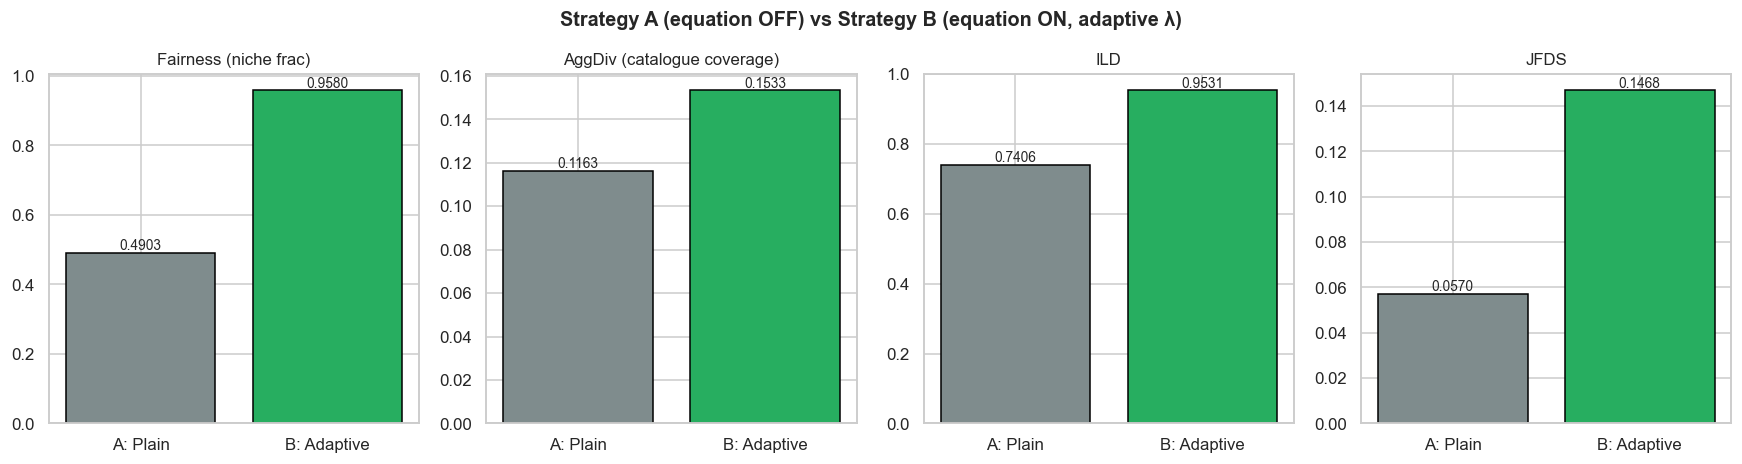

In [13]:
# ── Bar chart: Fairness / AggDiv / ILD / JFDS, A vs B ──────────────────────
metrics_to_plot = ['Fairness (niche frac)', 'AggDiv (catalogue coverage)', 'ILD', 'JFDS']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
colors = {'A — Plain Top-K (relevance only)': '#7F8C8D', 'B — Adaptive-λ JScore': '#27AE60'}

for ax, metric in zip(axes, metrics_to_plot):
    vals = summary_df[metric]
    bars = ax.bar(vals.index, vals.values, color=[colors[i] for i in vals.index], edgecolor='black')
    ax.set_title(metric, fontsize=11)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(['A: Plain', 'B: Adaptive'], rotation=0)
    for b, v in zip(bars, vals.values):
        ax.text(b.get_x() + b.get_width()/2, v, f'{v:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.suptitle('Strategy A (equation OFF) vs Strategy B (equation ON, adaptive λ)', y=1.05, fontsize=13, fontweight='bold')
plt.show()


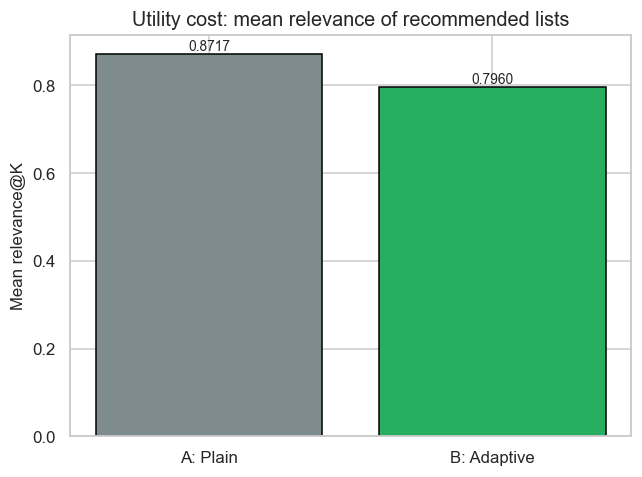

Relevance drop (A → B): 0.0757


In [14]:
# ── Utility trade-off: relevance given up for fairness/diversity gained ────
fig, ax = plt.subplots(figsize=(6, 4.5))
rel_vals = summary_df['Mean rel@K (utility)']
bars = ax.bar(rel_vals.index, rel_vals.values, color=[colors[i] for i in rel_vals.index], edgecolor='black')
ax.set_ylabel('Mean relevance@K')
ax.set_title('Utility cost: mean relevance of recommended lists')
ax.set_xticks(range(len(rel_vals)))
ax.set_xticklabels(['A: Plain', 'B: Adaptive'], rotation=0)
for b, v in zip(bars, rel_vals.values):
    ax.text(b.get_x() + b.get_width()/2, v, f'{v:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

rel_drop = summary_df.loc['A — Plain Top-K (relevance only)', 'Mean rel@K (utility)'] - \
           summary_df.loc['B — Adaptive-λ JScore', 'Mean rel@K (utility)']
print(f'Relevance drop (A → B): {rel_drop:.4f}')


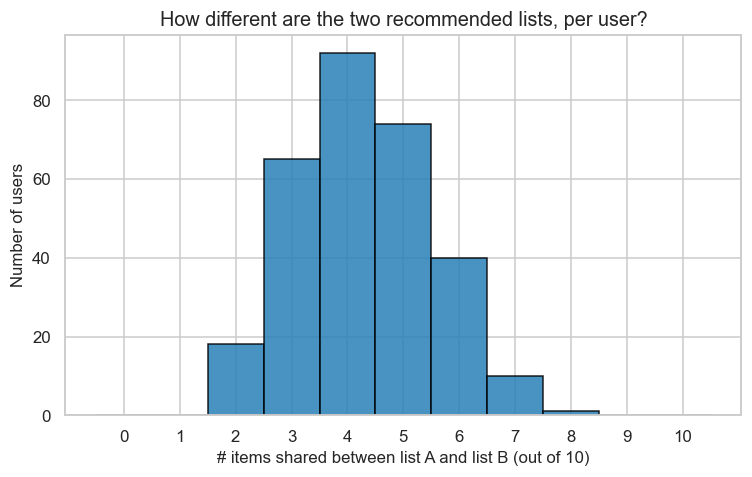

Mean overlap: 4.29 / 10


In [15]:
# ── Histogram: per-user list overlap between A and B ───────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(overlap_counts, bins=np.arange(0, K_RECS+2)-0.5, color='#2980B9', edgecolor='black', alpha=0.85)
ax.set_xlabel(f'# items shared between list A and list B (out of {K_RECS})')
ax.set_ylabel('Number of users')
ax.set_title('How different are the two recommended lists, per user?')
ax.set_xticks(range(0, K_RECS+1))
plt.tight_layout()
plt.show()

print(f'Mean overlap: {np.mean(overlap_counts):.2f} / {K_RECS}')


In [16]:
# ── Delta table: % change from A to B for every metric ─────────────────────
delta_rows = []
for metric in metrics_to_plot + ['Mean rel@K (utility)']:
    a_val = summary_df.loc['A — Plain Top-K (relevance only)', metric]
    b_val = summary_df.loc['B — Adaptive-λ JScore', metric]
    pct_change = (b_val - a_val) / a_val * 100 if a_val != 0 else np.nan
    delta_rows.append({'Metric': metric, 'A (plain)': a_val, 'B (adaptive)': b_val,
                       'Δ (B - A)': b_val - a_val, '% change': pct_change})

delta_df = pd.DataFrame(delta_rows)
print('=== Delta table: equation OFF vs equation ON ===')
print(delta_df.to_string(index=False))


=== Delta table: equation OFF vs equation ON ===
                     Metric  A (plain)  B (adaptive)  Δ (B - A)   % change
      Fairness (niche frac)   0.490333      0.958000   0.467667  95.377294
AggDiv (catalogue coverage)   0.116298      0.153265   0.036967  31.786543
                        ILD   0.740593      0.953105   0.212512  28.694827
                       JFDS   0.057025      0.146828   0.089803 157.480982
       Mean rel@K (utility)   0.871677      0.796009  -0.075668  -8.680734


---
## Part 6 — Genre Composition Comparison

A different angle on "how different are the lists": compare the aggregate
genre distribution of everything Strategy A recommended vs. everything
Strategy B recommended, across all sampled users.


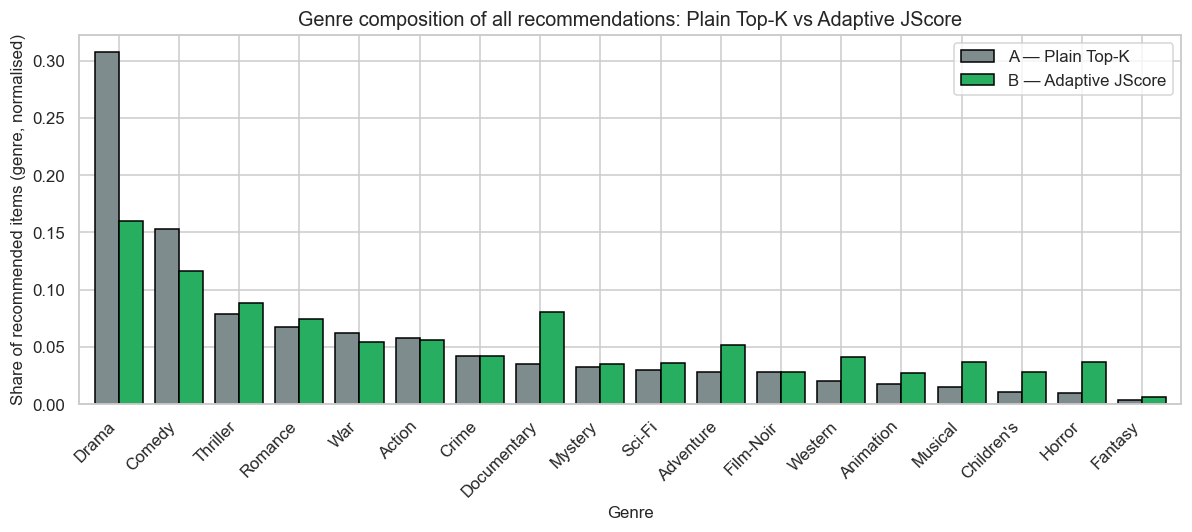

Genre distribution table:
             A — Plain Top-K  B — Adaptive JScore
Genre                                            
Drama               0.307172             0.159851
Comedy              0.152909             0.116481
Thriller            0.078484             0.087980
Romance             0.067659             0.074349
War                 0.062246             0.054523
Action              0.058187             0.055762
Crime               0.041949             0.042131
Documentary         0.035183             0.080545
Mystery             0.032476             0.034696
Sci-Fi              0.029770             0.035936
Adventure           0.028417             0.052045
Film-Noir           0.028417             0.028501
Western             0.020298             0.040892
Animation           0.017591             0.027261
Musical             0.014885             0.037175
Children's          0.010825             0.028501
Horror              0.009472             0.037175
Fantasy             0.00

In [17]:
# ── Aggregate genre distribution: A vs B ────────────────────────────────────
def genre_distribution(selected_ids_set):
    sel_movies = movies[movies['MovieID'].isin(selected_ids_set)].copy()
    sel_movies['Genre'] = sel_movies['Genres'].str.split('|')
    exploded = sel_movies.explode('Genre')
    counts = exploded['Genre'].value_counts(normalize=True)
    return counts

genre_dist_a = genre_distribution(results_a['all_selected_ids'])
genre_dist_b = genre_distribution(results_b['all_selected_ids'])

genre_compare = pd.DataFrame({'A — Plain Top-K': genre_dist_a, 'B — Adaptive JScore': genre_dist_b}).fillna(0)
genre_compare = genre_compare.sort_values('A — Plain Top-K', ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
genre_compare.plot(kind='bar', ax=ax, color=['#7F8C8D', '#27AE60'], edgecolor='black', width=0.8)
ax.set_ylabel('Share of recommended items (genre, normalised)')
ax.set_title('Genre composition of all recommendations: Plain Top-K vs Adaptive JScore')
ax.legend(title=None)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Genre distribution table:')
print(genre_compare.to_string())


---
## Part 7 — Sensitivity Check: Does the Schedule Shape Matter?

Repeat the comparison for a couple of alternative λ-schedules (different
`p` exponent, different start/end weights) to see whether the conclusions
in Part 4–6 depend heavily on the particular schedule chosen, or hold up
across reasonable variations.

> This loops the same `build_topk_adaptive` logic from Part 4 over a small
> set of named schedules. It does not re-run Strategy A (already fixed).


In [18]:
# ── Alternative schedules to test ───────────────────────────────────────────
ALT_SCHEDULES = {
    'linear (used above)':      dict(lf_start=0.05, lf_end=0.45, ld_start=0.05, ld_end=0.35, p=1.0),
    'front-loaded (p=0.5)':     dict(lf_start=0.05, lf_end=0.45, ld_start=0.05, ld_end=0.35, p=0.5),
    'back-loaded (p=2.0)':      dict(lf_start=0.05, lf_end=0.45, ld_start=0.05, ld_end=0.35, p=2.0),
    'wider range (0.0 → 0.6)':  dict(lf_start=0.00, lf_end=0.60, ld_start=0.00, ld_end=0.40, p=1.0),
}

N_USERS_SENS = 150  # smaller sample for the sensitivity sweep, for speed
sampled_users_sens = (
    ratings['UserID'].drop_duplicates()
    .sample(N_USERS_SENS, random_state=123)
    .values
)

sens_rows = []

for schedule_name, sched_params in ALT_SCHEDULES.items():
    all_selected_ids = set()
    niche_fracs, ilds, mean_rels = [], [], []

    for uid in sampled_users_sens:
        rated_ids = user_rated.get(uid, set())
        mask      = ~item_stats_idx['MovieID'].isin(rated_ids)
        cand_pool = item_stats_idx[mask]
        n_cand    = min(N_CANDIDATES, len(cand_pool))
        cand_df   = cand_pool.sample(n_cand, random_state=int(uid)).reset_index(drop=True)
        cand_idxs = [mid_to_idx[mid] for mid in cand_df['MovieID']]

        pos, _   = build_topk_adaptive(cand_df, cand_idxs, K=K_RECS, schedule_params=sched_params)
        sel      = cand_df.iloc[pos]
        sel_mids = sel['MovieID'].tolist()
        sel_gidxs = [mid_to_idx[m] for m in sel_mids]

        all_selected_ids.update(sel_mids)
        niche_fracs.append(1.0 - sel['is_popular'].mean())
        mean_rels.append(sel['rel'].mean())
        ild_val = ild_for_list(sel_gidxs)
        if ild_val is not None:
            ilds.append(ild_val)

    fairness = float(np.mean(niche_fracs))
    agg_div  = len(all_selected_ids) / n_items_catalogue
    ild      = float(np.mean(ilds)) if ilds else 0.0
    jfds     = fairness * agg_div

    sens_rows.append({
        'Schedule': schedule_name,
        'Fairness': fairness, 'AggDiv': agg_div, 'ILD': ild, 'JFDS': jfds,
        'Mean rel@K': float(np.mean(mean_rels)),
    })
    print(f'{schedule_name:<28s} → Fairness={fairness:.4f}  AggDiv={agg_div:.4f}  ILD={ild:.4f}  JFDS={jfds:.5f}')

sens_df = pd.DataFrame(sens_rows)
print()
print('=== Sensitivity sweep across λ-schedules ===')
print(sens_df.to_string(index=False))


linear (used above)          → Fairness=0.9607  AggDiv=0.1214  ILD=0.9575  JFDS=0.11665
front-loaded (p=0.5)         → Fairness=0.9640  AggDiv=0.1244  ILD=0.9653  JFDS=0.11991
back-loaded (p=2.0)          → Fairness=0.9173  AggDiv=0.1209  ILD=0.9394  JFDS=0.11089
wider range (0.0 → 0.6)      → Fairness=0.9167  AggDiv=0.1508  ILD=0.9715  JFDS=0.13827

=== Sensitivity sweep across λ-schedules ===
               Schedule  Fairness   AggDiv      ILD     JFDS  Mean rel@K
    linear (used above)  0.960667 0.121425 0.957518 0.116649    0.797319
   front-loaded (p=0.5)  0.964000 0.124393 0.965300 0.119915    0.791281
    back-loaded (p=2.0)  0.917333 0.120885 0.939379 0.110892    0.814965
wider range (0.0 → 0.6)  0.916667 0.150836 0.971528 0.138267    0.771016


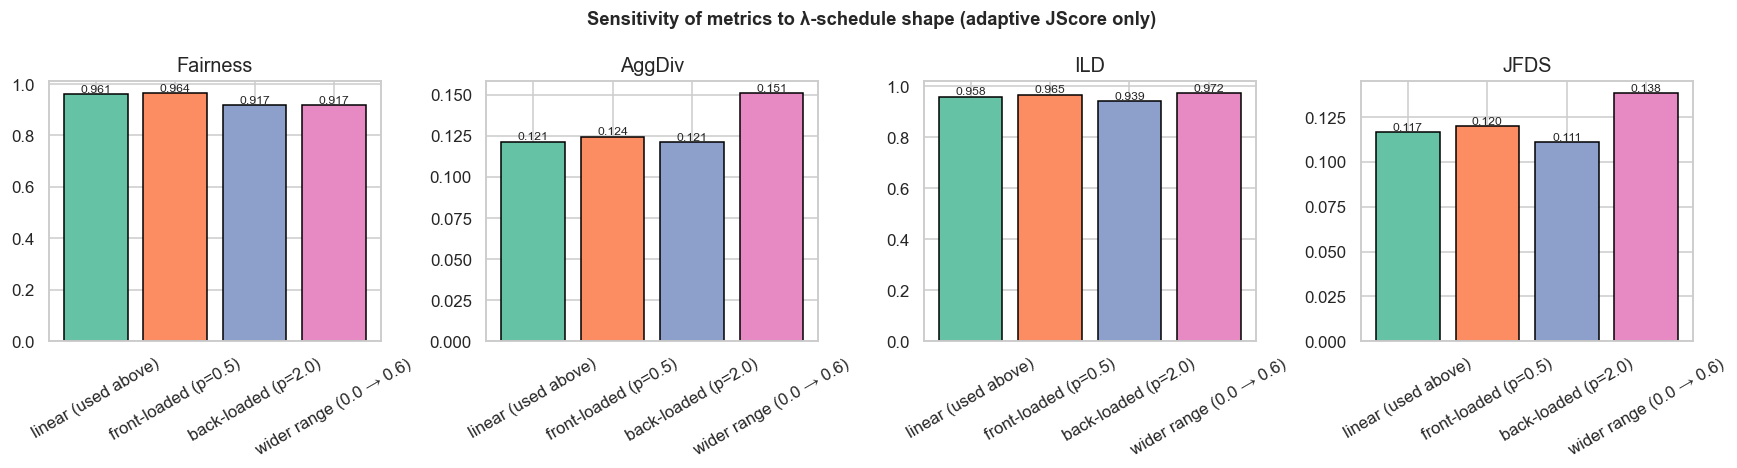

In [19]:
# ── Visual: sensitivity sweep results ──────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
metrics_sens = ['Fairness', 'AggDiv', 'ILD', 'JFDS']

for ax, metric in zip(axes, metrics_sens):
    bars = ax.bar(sens_df['Schedule'], sens_df[metric], color=sns.color_palette('Set2', len(sens_df)), edgecolor='black')
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=30)
    for b, v in zip(bars, sens_df[metric]):
        ax.text(b.get_x()+b.get_width()/2, v, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.suptitle('Sensitivity of metrics to λ-schedule shape (adaptive JScore only)', y=1.06, fontsize=12, fontweight='bold')
plt.show()


---
## Part 8 — Summary Table (fill in after running)

This cell just assembles everything computed above into one final table.
No new computation, no interpretation — that part is yours.


In [20]:
# ── Final consolidated summary ──────────────────────────────────────────────
print('=' * 70)
print('EXPERIMENT SUMMARY — Plain Top-K vs Adaptive-λ JScore (MovieLens 1M)')
print('=' * 70)
print()
print(f'Users sampled (main comparison) : {N_USERS}')
print(f'List length K                   : {K_RECS}')
print(f'Candidates per user              : {N_CANDIDATES}')
print(f'λ schedule (main comparison)     : {SCHEDULE_PARAMS}')
print()
print('--- Headline metrics: A (plain) vs B (adaptive JScore) ---')
print(summary_df.to_string())
print()
print('--- Delta table ---')
print(delta_df.to_string(index=False))
print()
print('--- Per-user list overlap@K ---')
print(f'Mean overlap@{K_RECS}: {np.mean(overlap_counts):.2f}  |  Median: {np.median(overlap_counts):.1f}  |  '
      f'Users with 0 overlap: {(np.array(overlap_counts)==0).sum()} / {len(overlap_counts)}')
print()
print('--- Sensitivity sweep across schedule shapes ---')
print(sens_df.to_string(index=False))
print('=' * 70)


EXPERIMENT SUMMARY — Plain Top-K vs Adaptive-λ JScore (MovieLens 1M)

Users sampled (main comparison) : 300
List length K                   : 10
Candidates per user              : 150
λ schedule (main comparison)     : {'lf_start': 0.05, 'lf_end': 0.45, 'ld_start': 0.05, 'ld_end': 0.35, 'p': 1.0}

--- Headline metrics: A (plain) vs B (adaptive JScore) ---
                                  Fairness (niche frac)  AggDiv (catalogue coverage)       ILD      JFDS  Mean rel@K (utility)
Strategy                                                                                                                      
A — Plain Top-K (relevance only)               0.490333                     0.116298  0.740593  0.057025              0.871677
B — Adaptive-λ JScore                          0.958000                     0.153265  0.953105  0.146828              0.796009

--- Delta table ---
                     Metric  A (plain)  B (adaptive)  Δ (B - A)   % change
      Fairness (niche frac)   0.490333